What LSTM DOES WELL

✔ Captures non-linear temporal patterns
✔ Handles sequences naturally
✔ Powerful for structured time series

❌ What LSTM DOES POORLY (IN MARKETS)

❌ Overfits easily
❌ Sensitive to regime changes
❌ Poor interpretability
❌ No economic understanding

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

plt.style.use("seaborn-v0_8")


C:\Users\KRISHNENDU\anaconda3\envs\etl-pipeline\lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\KRISHNENDU\anaconda3\envs\etl-pipeline\lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\KRISHNENDU\anaconda3\envs\etl-pipeline\lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.pr

Load Stock Data

In [2]:
ticker = "RELIANCE.NS"

df = yf.download(
    ticker,
    start="2015-01-01",
    end="2025-01-01"
)

df = df[['Close']].dropna()
df.head()


C:\Users\KRISHNENDU\AppData\Local\Temp\ipykernel_20888\3164813451.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,RELIANCE.NS
Date,
2015-01-01,189.999817
2015-01-02,189.496933
2015-01-05,187.421249
2015-01-06,178.915237
2015-01-07,182.809814


Scale the Data

In [3]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df[['Close']])


Create Sequences (Sliding Window)

In [4]:
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, window_size=60)

X.shape, y.shape


((2407, 60), (2407,))

Train–Test Split (Time-Based)

In [5]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


Define LSTM Architecture

In [6]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(60,1)))
model.add(Dropout(0.2))

model.add(LSTM(50))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()


C:\Users\KRISHNENDU\anaconda3\envs\etl-pipeline\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Train the Model

In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)


Epoch 1/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 5.7869e-04 - val_loss: 5.4161e-04
Epoch 2/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 5.3433e-04 - val_loss: 6.4185e-04
Epoch 3/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 5.7527e-04 - val_loss: 3.5608e-04
Epoch 4/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 5.8573e-04 - val_loss: 7.7772e-04
Epoch 5/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 5.9605e-04 - val_loss: 4.4328e-04
Epoch 6/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 4.6886e-04 - val_loss: 5.1717e-04
Epoch 7/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 5.0385e-04 - val_loss: 6.2279e-04
Epoch 8/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 5.4893e-04 - val_loss: 3.8729e-04
Epoch 9/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 5.5826e-04 - val_loss: 6.8571e-04
Epoch 10/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 5.0367e-04 - val_loss: 3.6841e-04
Epoch 11/100
109/109 ━━━━━━━━━━━━━━━━━━

Predict on Test Data

In [16]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


Evaluate Performance

In [17]:
mae = mean_absolute_error(y_test_actual, predictions)
print("MAE:", mae)


MAE: 15.92109927102243


Plot LSTM Predictions vs Actual

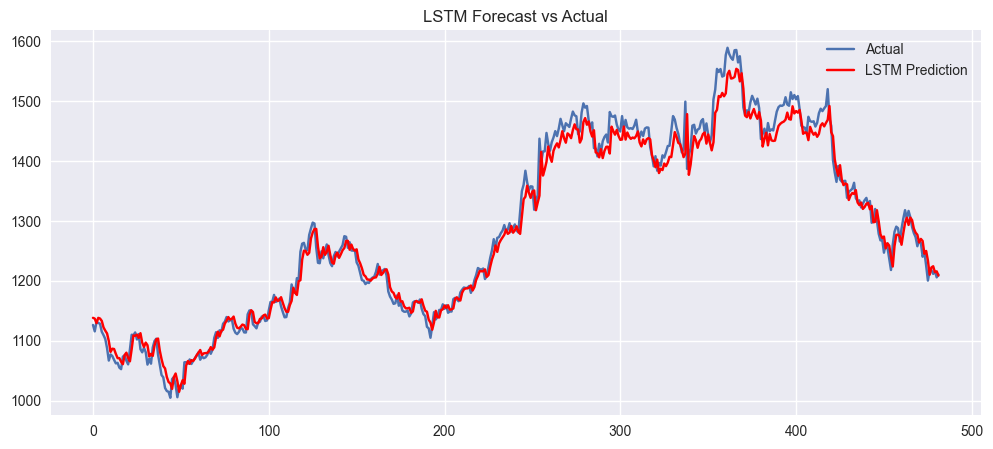

In [18]:
plt.figure(figsize=(12,5))
plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="LSTM Prediction", color='red')
plt.legend()
plt.title("LSTM Forecast vs Actual")
plt.show()
